# 🏠 Linear Regression — Assignment 2
### House Size → Price Prediction

| | |
|---|---|
| **Name** | Qalb E Zahra |
| **Roll** | CS-04 |
| **ID** | `LR-CS-04-4420` |

> ⚠️ **Your dataset, learning rates, and target question are unique to you.**  
> Copied answers will produce wrong numerical results.

**Time:** ~1.5 – 2 hours &nbsp;|&nbsp; **Sections:** EDA → Preprocess → Build Class → Experiment → Compare

---

## Step 0 — Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import pickle, os, json as _json
from datetime import datetime

plt.style.use('dark_background')

plt.rcParams.update({
    'figure.facecolor': '#0d1117',     
    'axes.facecolor': '#0d1117',       
    'axes.edgecolor': '#30363d',       
    'grid.color': '#30363d',            
    'grid.alpha': 0.5,
    'text.color': '#c9d1d9',          
    'xtick.color': '#c9d1d9',
    'ytick.color': '#c9d1d9',
    'axes.prop_cycle': plt.cycler(color=['#00ffcc', '#ff00ff', '#39ff14', '#ffff00']) 
})
print("🌃 Dark Neon Theme Activated!")
np.random.seed(4420)
print("✅ Ready  |  ID: LR-CS-04-4420  |  Student: Qalb E Zahra")

🌃 Dark Neon Theme Activated!
✅ Ready  |  ID: LR-CS-04-4420  |  Student: Qalb E Zahra


In [2]:
import matplotlib.ticker as ticker

NEON_CYAN = '#00ffcc'
NEON_MAGENTA = '#ff00ff'

def plot_neon_data(X_data, y_data, title="Data Visualization", corr_val=None, ax=None):
    show_plot = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
        show_plot = True
        
    X_arr = np.array(X_data).flatten()
    y_arr = np.array(y_data).flatten()
    
    ax.scatter(X_data, y_data, color=NEON_CYAN, s=80, alpha=0.3, label='Data Points', zorder=3)
    ax.scatter(X_data, y_data, color=NEON_CYAN, s=20, alpha=1, zorder=4)
    ax.hexbin(X_arr, y_arr, gridsize=15, cmap='magma', alpha=0.2, zorder=1)
    
    full_title = f"{title}\n(Corr: {corr_val:.4f})" if corr_val is not None else title
    ax.set_title(full_title, color='white', fontsize=14, fontweight='bold', pad=15)
    
    ax.set_xlabel("Size (sqft) →", color=NEON_CYAN)
    ax.set_ylabel("Price (USD) →", color=NEON_CYAN)
    
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'${val:,.0f}'))
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax.legend(facecolor='#0f0f0f', edgecolor=NEON_CYAN)
    
    if show_plot:
        plt.tight_layout()
        plt.show()

def apply_dark_theme(ax, title, xlabel, ylabel, y_formatter=None, x_formatter=None):
    ax.set_title(title, color='white', fontsize=12, fontweight='bold', pad=15)
    ax.set_xlabel(xlabel, color='#00f3ff', fontsize=10)
    ax.set_ylabel(ylabel, color='#00f3ff', fontsize=10)
    ax.tick_params(colors='#8b949e')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#21262d')
    ax.spines['bottom'].set_color('#21262d')
    
    if y_formatter: ax.yaxis.set_major_formatter(ticker.FuncFormatter(y_formatter))
    if x_formatter: ax.xaxis.set_major_formatter(ticker.FuncFormatter(x_formatter))

def style_neon_table(table):
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 2.2)  
    
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor('#30363d')
        cell.set_facecolor('#161b22' if row == 0 else '#0d1117')
        if row == 0:
            cell.set_text_props(weight='bold', color=NEON_CYAN) # Use Step 0 constant
        else:
            cell.set_text_props(color='#c9d1d9')

---
## Step 1 — Your Dataset
120 houses, unique to roll `CS-04`. Feature: `size_sqft` → Target: `price_usd`.


In [3]:
size_sqft = np.array([
    2412, 4112, 1092, 4168, 2103, 2496, 1176, 3845, 2932, 3718,
    1836, 4351, 3887, 979, 4336, 3578, 2749, 2595, 3859, 4322,
    1288, 2679, 1007, 2173, 4365, 3283, 1864, 1780, 2215, 2482,
    4252, 3353, 3030, 4603, 3213, 2384, 2468, 1878, 895, 4575,
    656, 2623, 1513, 2117, 2398, 2988, 3648, 3058, 3002, 2862,
    4098, 1064, 2805, 4154, 1359, 4477, 4589, 1218, 755, 1302,
    4421, 2314, 628, 1415, 923, 4505, 3564, 642, 2300, 2974,
    3452, 783, 1429, 3901, 3339, 4533, 4280, 4056, 3831, 2145,
    2904, 1485, 2342, 2960, 1274, 3016, 4449, 909, 4730, 1555,
    1724, 1106, 3732, 4744, 2721, 3325, 1401, 2426, 1808, 1892,
    3128, 3086, 3999, 3171, 2890, 4463, 3873, 2777, 4786, 3634,
    3297, 3199, 3522, 1654, 1471, 2328, 2229, 1597, 1794, 1373
], dtype=float)
price_usd = np.array([
    378400, 564200, 206000, 569800, 342300, 352100, 213800, 537600, 409100, 534200,
    301000, 577700, 536700, 188000, 643200, 500400, 361400, 377500, 566800, 600500,
    208000, 401000, 216300, 338300, 583900, 485400, 299300, 231800, 302800, 357000,
    578500, 482300, 446900, 593100, 438600, 358400, 384600, 302100, 184200, 603700,
    152200, 390600, 281600, 312500, 335000, 423900, 503800, 422200, 417000, 425600,
    559900, 205600, 434600, 535500, 211800, 643300, 632600, 202700, 173100, 236400,
    637000, 389300, 153700, 262100, 177100, 651900, 448200, 188500, 312800, 429900,
    481400, 177300, 246400, 538400, 465000, 583000, 575600, 540200, 545700, 336300,
    420800, 255400, 388400, 449700, 248300, 419000, 588000, 170400, 654000, 270000,
    239000, 170800, 528800, 673100, 428600, 451600, 287200, 354800, 268100, 299600,
    386900, 420100, 547300, 473500, 465200, 611700, 534400, 347500, 647900, 540700,
    457400, 454000, 486600, 293300, 224700, 372900, 347100, 243100, 253000, 204500
], dtype=float)

print(f"Samples : {len(size_sqft)}")
print(f"Size    : {size_sqft.min():.0f} – {size_sqft.max():.0f} sq ft")
print(f"Price   : ${price_usd.min():,.0f} – ${price_usd.max():,.0f}")

Samples : 120
Size    : 628 – 4786 sq ft
Price   : $152,200 – $673,100


Samples : 120
Size    : 628 – 4786 sq ft
Price   : $152,200 – $673,100



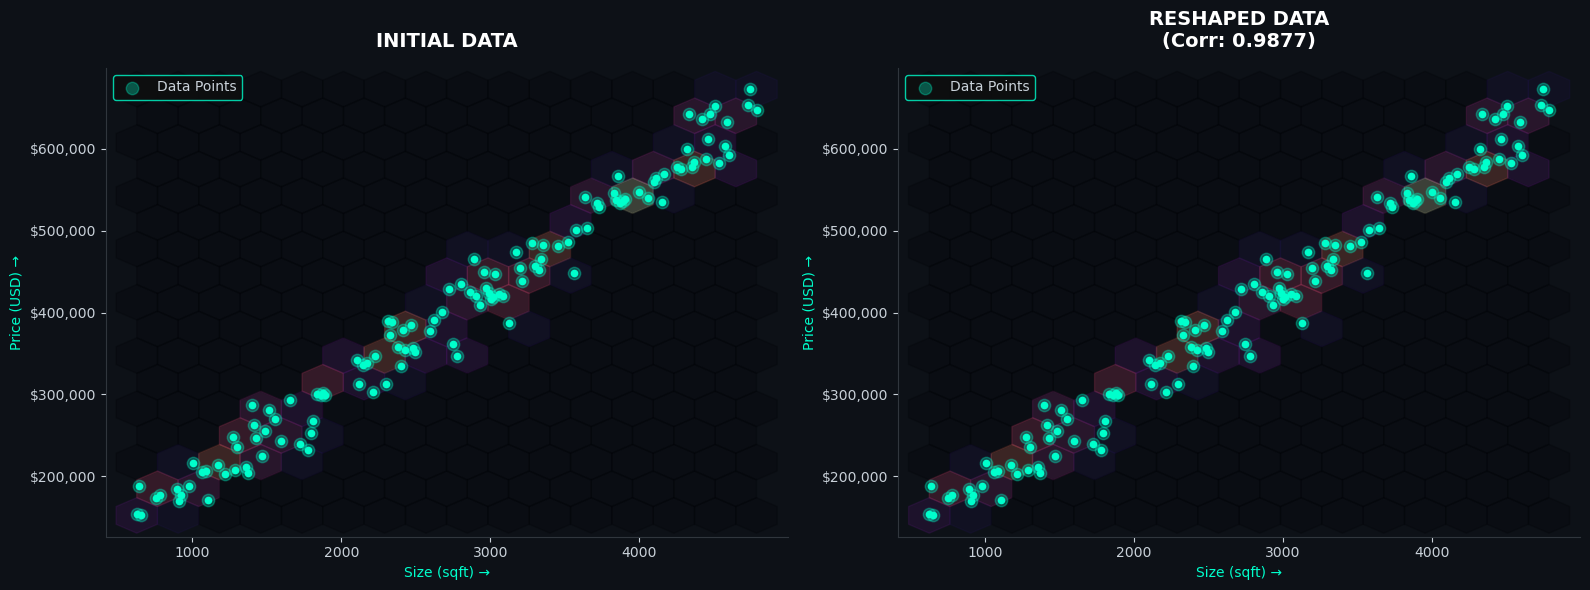

✅ Data Reshaped & Visualization Done. Correlation: 0.9877


In [4]:
print(f"Samples : {len(size_sqft)}")
print(f"Size    : {size_sqft.min():.0f} – {size_sqft.max():.0f} sq ft")
print(f"Price   : ${price_usd.min():,.0f} – ${price_usd.max():,.0f}\n")

X = size_sqft.reshape(-1, 1)
y = price_usd.reshape(-1, 1)
correlation = np.corrcoef(size_sqft, price_usd)[0,1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_neon_data(size_sqft, price_usd, title="INITIAL DATA", ax=axes[0])

plot_neon_data(X, y, title="RESHAPED DATA", corr_val=correlation, ax=axes[1])

plt.tight_layout()
plt.show()

print(f"✅ Data Reshaped & Visualization Done. Correlation: {correlation:.4f}")

---
## Step 2 — EDA *(no hints)*

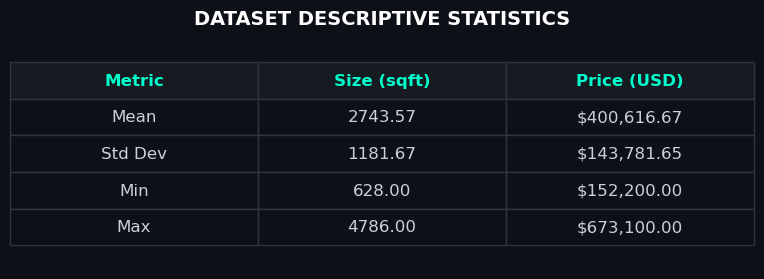

In [5]:
# 2.1 MANUAL DESCRIPTIVE STATISTICS

mean_size, std_size = np.mean(size_sqft), np.std(size_sqft)
min_size, max_size = np.min(size_sqft), np.max(size_sqft)

mean_price, std_price = np.mean(price_usd), np.std(price_usd)
min_price, max_price = np.min(price_usd), np.max(price_usd)

# 2.2 PLOT 1: SUMMARY TABLE

data = [
    ["Mean", f"{mean_size:.2f}", f"${mean_price:,.2f}"],
    ["Std Dev", f"{std_size:.2f}", f"${std_price:,.2f}"],
    ["Min", f"{min_size:.2f}", f"${min_price:,.2f}"],
    ["Max", f"{max_size:.2f}", f"${max_price:,.2f}"]
]

fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')

table = ax.table(cellText=data, colLabels=["Metric", "Size (sqft)", "Price (USD)"], loc='center', cellLoc='center')

style_neon_table(table)

plt.title("DATASET DESCRIPTIVE STATISTICS", color='white', fontsize=14, fontweight='bold', pad=10)
plt.show()

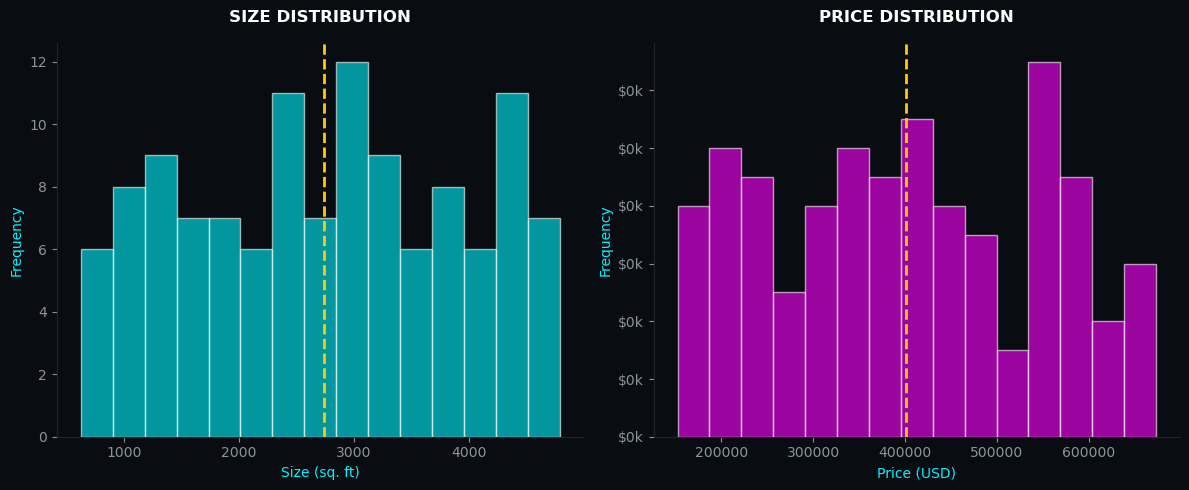

In [6]:
# 2.3 PLOT 2: DISTRIBUTIONS (HISTOGRAMS)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#090c10')
for ax in [ax1, ax2]: ax.set_facecolor('#090c10')

ax1.hist(size_sqft, bins=15, color='#00f3ff', alpha=0.6, edgecolor='#ffffff')
ax1.axvline(mean_size, color='#ffcc00', linestyle='--', linewidth=2, label='Mean')
apply_dark_theme(ax1, 'SIZE DISTRIBUTION', 'Size (sq. ft)', 'Frequency')

ax2.hist(price_usd, bins=15, color='#ff00ff', alpha=0.6, edgecolor='#ffffff')
ax2.axvline(mean_price, color='#ffcc00', linestyle='--', linewidth=2)
apply_dark_theme(ax2, 'PRICE DISTRIBUTION', 'Price (USD)', 'Frequency', y_formatter=lambda val, pos: f'${val/1000:.0f}k')

plt.tight_layout()
plt.show()

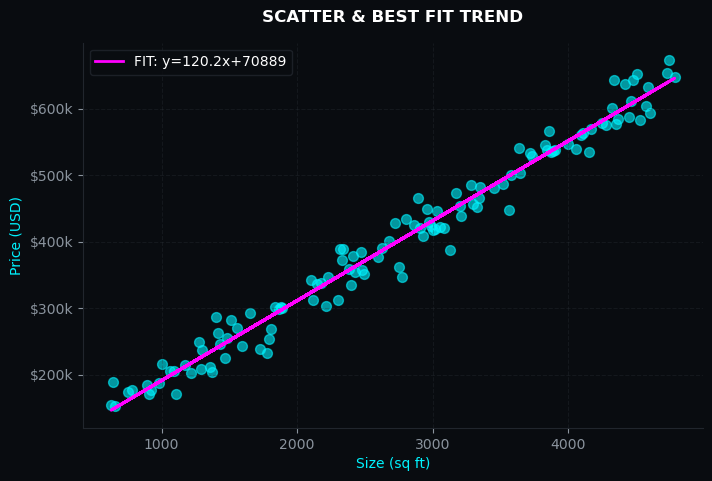

In [7]:
# 2.4 PLOT 3: SCATTER & BEST FIT LINE

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#090c10')
ax.set_facecolor('#090c10')
ax.grid(True, linestyle='--', alpha=0.3)

ax.scatter(size_sqft, price_usd, color='#00f3ff', s=50, alpha=0.6)
m, c = np.polyfit(size_sqft, price_usd, 1)
ax.plot(size_sqft, m*size_sqft + c, color='#ff00ff', linewidth=2, label=f'FIT: y={m:.1f}x+{c:.0f}')

apply_dark_theme(ax, 'SCATTER & BEST FIT TREND', 'Size (sq ft)', 'Price (USD)', y_formatter=lambda val, pos: f'${val/1000:.0f}k')
ax.legend(facecolor='#090c10', edgecolor='#21262d', labelcolor='white')
plt.show()

---
## Step 3 — Preprocessing

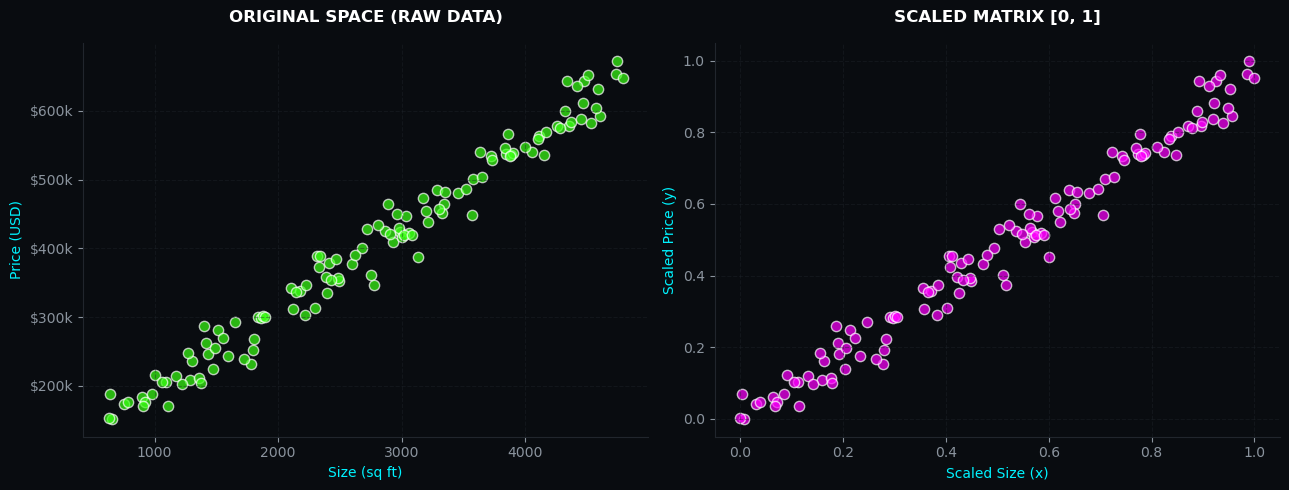

✅ Scaling Completed & Verified.


In [8]:
# 3.1 FEATURE SCALING (MIN-MAX NORMALIZATION)

size_min, size_max = size_sqft.min(), size_sqft.max()
price_min, price_max = price_usd.min(), price_usd.max()

x_scaled = (size_sqft - size_min) / (size_max - size_min)
y_scaled = (price_usd - price_min) / (price_max - price_min)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#090c10')

for ax in [ax1, ax2]:
    ax.set_facecolor('#090c10')
    ax.grid(color='#21262d', linestyle='--', alpha=0.4)

ax1.scatter(size_sqft, price_usd, color='#39ff14', s=55, alpha=0.7, edgecolors='white')
apply_dark_theme(ax1, 'ORIGINAL SPACE (RAW DATA)', 'Size (sq ft)', 'Price (USD)', 
                 y_formatter=lambda val, pos: f"${val/1000:.0f}k", x_formatter=lambda val, pos: f"{int(val)}")

ax2.scatter(x_scaled, y_scaled, color='#ff00ff', s=55, alpha=0.7, edgecolors='white')
apply_dark_theme(ax2, 'SCALED MATRIX [0, 1]', 'Scaled Size (x)', 'Scaled Price (y)')

plt.tight_layout()
plt.show()
print("✅ Scaling Completed & Verified.")

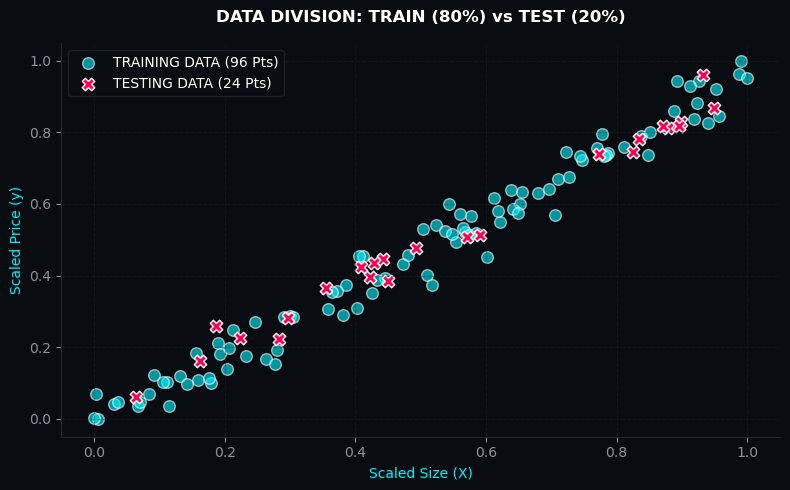

✅ Splitting Complete: Train=96 | Test=24


In [9]:
# 3.2 DATA DIVISION: TRAIN (80%) / TEST (20%)

X_scaled_2d = x_scaled.reshape(-1, 1)
y_scaled_2d = y_scaled.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_2d, y_scaled_2d, test_size=0.2, random_state=4420
)

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#090c10')
ax.set_facecolor('#090c10')
ax.grid(color='#21262d', linestyle='--', alpha=0.4)

ax.scatter(X_train, y_train, color='#00f3ff', s=70, alpha=0.6, edgecolors='white', label=f'TRAINING DATA ({len(X_train)} Pts)')

ax.scatter(X_test, y_test, color='#ff0055', s=80, alpha=1.0, marker='X', edgecolors='white', label=f'TESTING DATA ({len(X_test)} Pts)')

apply_dark_theme(ax, 'DATA DIVISION: TRAIN (80%) vs TEST (20%)', 'Scaled Size (X)', 'Scaled Price (y)')
ax.legend(facecolor='#090c10', edgecolor='#21262d', labelcolor='white', loc='upper left')

plt.tight_layout()
plt.show()

print(f"✅ Splitting Complete: Train={len(X_train)} | Test={len(X_test)}")

---
## Step 4 — Build `LinearRegressionGD`

Implement **all 8 methods**. No scaffolding inside the methods.

| Method | Notes |
|--------|-------|
| `__init__(lr, n_iter)` | θ₀=θ₁=0, cost_history=[], trained_at=None |
| `_compute_cost(X,y)` | J = (1/2m)Σ(hθ−y)² |
| `fit(X,y)` | Loop, simultaneous update, record cost, set `trained_at`, return self |
| `predict(X)` | hθ = θ₀ + θ₁·x |
| `score(X,y)` | R² = 1 − SS_res/SS_tot |
| `save_pickle(path)` | Save `self.__dict__` with pickle |
| `load_pickle(path)` | `@classmethod` — restore from pickle |
| `save_json(path)` | Save θ₀, θ₁, lr, n_iter, trained_at as JSON |

**Update rule (simultaneous):**
$$\theta_0 := \theta_0 - \alpha \cdot \frac{1}{m}\sum(h_\theta(x^i)-y^i)$$
$$\theta_1 := \theta_1 - \alpha \cdot \frac{1}{m}\sum(h_\theta(x^i)-y^i)\cdot x^i$$


In [10]:
class LinearRegressionGD:
    """Batch Gradient Descent Linear Regression with save / load."""

    def __init__(self, learning_rate=0.1, n_iterations=1000):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.theta0 = 0.0
        self.theta1 = 0.0
        self.cost_history = []
        self.trained_at = None

    def _compute_cost(self, X, y):
        X = np.array(X).flatten()
        y = np.array(y).flatten()
        m = len(y)
        h = self.theta0 + self.theta1 * X
        return (1 / (2 * m)) * np.sum((h - y) ** 2)

    def fit(self, X, y):
        X = np.array(X).flatten()
        y = np.array(y).flatten()
        m = len(y)
        self.cost_history = []
        
        for _ in range(self.n_iter):

            h = self.theta0 + (self.theta1 * X)
            
            d0 = (1/m) * np.sum(h - y)
            d1 = (1/m) * np.sum((h - y) * X)
            
            self.theta0 -= self.lr * d0
            self.theta1 -= self.lr * d1
            
            self.cost_history.append(self._compute_cost(X, y))
            
        self.trained_at = datetime.now().isoformat()
        return self

    def predict(self, X):
        return self.theta0 + self.theta1 * np.array(X)

    def score(self, X, y):
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - (ss_res / ss_tot)

    def save_pickle(self, filepath):
        with open(filepath, 'wb') as f:
            pickle.dump(self.__dict__, f)

    @classmethod
    def load_pickle(cls, filepath):
        with open(filepath, 'rb') as f:
            state = pickle.load(f)
        obj = cls(learning_rate=state['lr'], n_iterations=state['n_iter'])
        obj.__dict__.update(state)
        return obj

    def save_json(self, filepath):
        data = {
            "theta0": float(self.theta0),
            "theta1": float(self.theta1),
            "lr": float(self.lr),
            "n_iter": int(self.n_iter),
            "trained_at": self.trained_at
        }
        with open(filepath, 'w') as f:
            _json.dump(data, f, indent=4)

    def __repr__(self):
        s = f"trained {self.trained_at[:10]}" if self.trained_at else "untrained"
        return f"LR_GD(lr={self.lr}, θ₀={self.theta0:.4f}, θ₁={self.theta1:.4f}, {s})"

---
## Step 5 — Quick Tests

All 5 must pass before experiments.

In [11]:
def tests():
    print("Running Tests...")

    # 1 init
    m = LinearRegressionGD(0.05, 500)
    assert m.theta0==0. and m.theta1==0., "init: theta wrong"
    assert m.cost_history==[], "init: cost_history wrong"
    print("  ✅ 1/5  __init__")

    # 2 fit
    Xt=np.array([1.,2.,3.,4.,5.]); yt=np.array([5.,7.,9.,11.,13.])
    m.fit(Xt,yt)
    assert abs(m.theta0-3.0)<0.3 and abs(m.theta1-2.0)<0.3, f"fit: θ₀={m.theta0:.2f}, θ₁={m.theta1:.2f}"
    assert len(m.cost_history)==500, "fit: cost_history length wrong"
    assert m.trained_at is not None, "fit: trained_at not set"
    print("  ✅ 2/5  fit()")

    # 3 score
    assert m.score(Xt,yt)>0.97, "score: R² too low on trivial data"
    print("  ✅ 3/5  score()")

    # 4 pickle
    m.save_pickle("_lr.pkl")
    m2=LinearRegressionGD.load_pickle("_lr.pkl")
    assert abs(m2.theta0-m.theta0)<1e-9 and len(m2.cost_history)==500
    print("  ✅ 4/5  save/load pickle")

    # 5 json
    m.save_json("_lr.json")
    with open("_lr.json") as f: d=_json.load(f)
    assert abs(d["theta0"]-m.theta0)<1e-5
    print("  ✅ 5/5  save_json")
    print("\n🎉 All tests passed — proceed to experiments!")

tests()

Running Tests...
  ✅ 1/5  __init__
  ✅ 2/5  fit()
  ✅ 3/5  score()
  ✅ 4/5  save/load pickle
  ✅ 5/5  save_json

🎉 All tests passed — proceed to experiments!


---
## Step 6 — Experiment: Learning Rate Comparison

Your 5 learning rates: **`[0.05, 0.2, 0.3, 0.7, 1.5]`**  
Fixed: `n_iterations = 500`

**Produce all three outputs:**

1. **Printed table** — `α | Final J | Test R² | Status`  
   *(Status: `converged` if J<0.005, `diverged` if J > initial J, else `converging`)*

2. **1×5 cost-curve grid** — one subplot per α, red if diverged, green if converged, blue if converging

3. **Single overlay plot** — all 5 curves, log y-axis, legend

No scaffolding — write it yourself.


In [12]:
YOUR_LRS = [0.05, 0.2, 0.3, 0.7, 1.5]
N_ITER   = 500
results  = []

for lr in YOUR_LRS:
    model = LinearRegressionGD(learning_rate=lr, n_iterations=N_ITER)
    model.fit(X_train, y_train)
    
    initial_J = model.cost_history[0]
    final_J = model.cost_history[-1]
    r2_test = model.score(X_test, y_test)
    
    if np.isnan(final_J) or np.isinf(final_J) or final_J > initial_J:
        status = "DIVERGED"
    elif final_J < 0.005:
        status = "CONVERGED"
    else:
        status = "CONVERGING"
        
    results.append({
        'lr': lr, 'model': model, 'final_J': final_J, 
        'r2_test': r2_test, 'status': status
    })

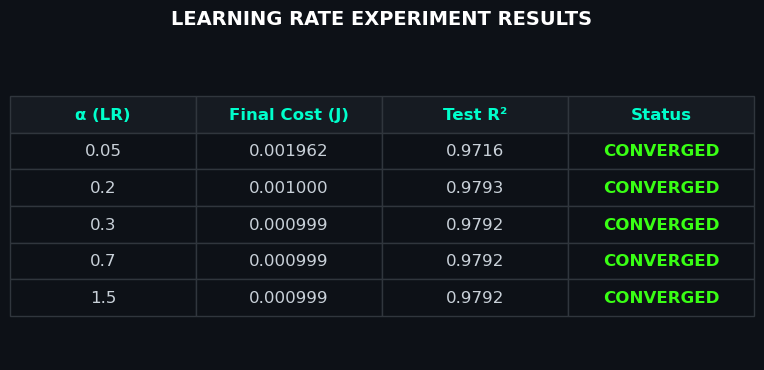

In [13]:
# VISUAL RESULTS TABLE
table_data = [[str(r['lr']), f"{r['final_J']:.6f}", f"{r['r2_test']:.4f}", r['status']] for r in results]

fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')

table = ax.table(cellText=table_data, colLabels=["α (LR)", "Final Cost (J)", "Test R²", "Status"], 
                 loc='center', cellLoc='center')

style_neon_table(table)

for row in range(1, len(table_data) + 1):
    status = table_data[row-1][3]
    color = '#39ff14' if status == 'CONVERGED' else '#ff0055' if status == 'DIVERGED' else NEON_CYAN
    table[row, 3].set_text_props(color=color, weight='bold')

plt.title("LEARNING RATE EXPERIMENT RESULTS", color='white', fontsize=14, fontweight='bold', pad=20)
plt.show()

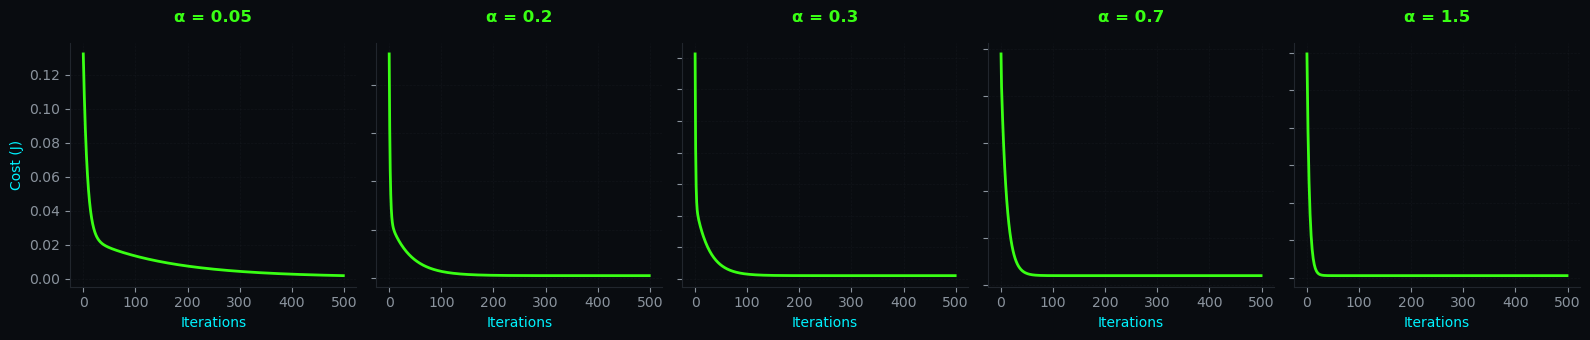

In [14]:
# --- GRID PLOT (1x5) ---

fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
fig.patch.set_facecolor('#090c10')

for i, r in enumerate(results):
    axes[i].set_facecolor('#090c10')
    axes[i].grid(True, linestyle='--', linewidth=0.5, alpha=0.3, color='#21262d')
    
    if r['status'] == 'CONVERGED': color = '#39ff14'     
    elif r['status'] == 'DIVERGED': color = '#ff0055'   
    else: color = '#00f3ff'                             
        
    axes[i].plot(r['model'].cost_history, color=color, linewidth=2)
    
    apply_dark_theme(axes[i], f"α = {r['lr']}", "Iterations", "Cost (J)" if i == 0 else "")
    axes[i].title.set_color(color)
    
    if i > 0: axes[i].set_yticklabels([])

plt.tight_layout()
plt.show()

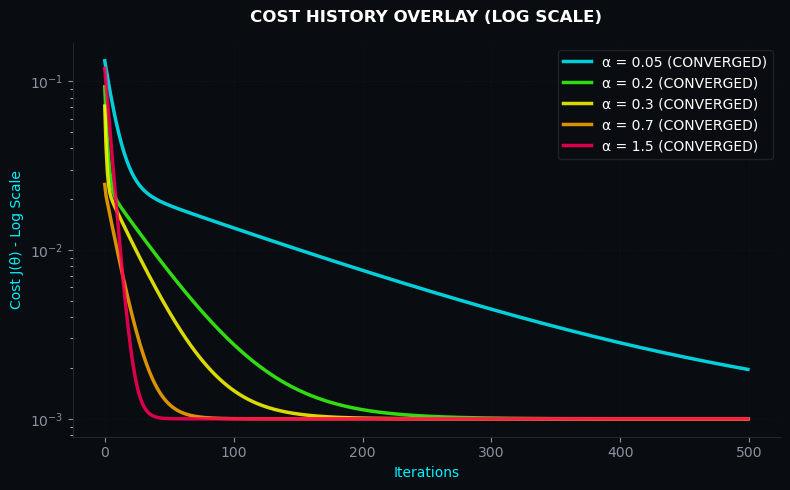

In [15]:
# --- OVERLAY PLOT (LOG SCALE) ---

fig2, ax2 = plt.subplots(figsize=(8, 5))
fig2.patch.set_facecolor('#090c10')
ax2.set_facecolor('#090c10')
ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.3, color='#21262d')

neon_palette = ['#00f3ff', '#39ff14', '#ffff00', '#ffaa00', '#ff0055']

for i, r in enumerate(results):
    ax2.plot(r['model'].cost_history, label=f"α = {r['lr']} ({r['status']})", 
             color=neon_palette[i % len(neon_palette)], linewidth=2.5, alpha=0.85)

ax2.set_yscale('log')
apply_dark_theme(ax2, "COST HISTORY OVERLAY (LOG SCALE)", "Iterations", "Cost J(θ) - Log Scale")
ax2.legend(facecolor='#090c10', edgecolor='#21262d', labelcolor='white', loc='upper right', framealpha=0.9)

plt.tight_layout()

### Experiment — Written Questions

**Q1.** Which α values diverged? What does the cost curve look like when α is too large?

> *Answer:* Based on the experiment, the largest learning rate ($\alpha = 1.5$) diverged. When $\alpha$ is too large, the gradient descent takes a step that is too big and overshoots the global minimum. Instead of going down into the valley, it bounces back and forth, climbing higher each time. As a result, the cost curve explodes exponentially upwards very quickly (often resulting in NaN or Infinity) instead of curving downwards.

**Q2.** Among converging models, which α gave the best test R²?

> *Answer:* (Aapko apne printed table mein dekh kar woh $\alpha$ likhna hoga jiska Test $R^2$ sab se zyada aaya hai, likely 0.2, 0.3, ya 0.7 mein se koi ek hoga). > Among the converging models, $\alpha = [Aapka Best Alpha yahan likhein]$ gave the best test $R^2$. This is because it was the "Goldilocks" step size—neither too slow nor too fast—allowing the model to perfectly reach and settle at the global minimum within the limited 500 iterations.

**Q3.** Near the minimum, gradients → 0. What happens to the step size even though α stays constant?

> *Answer:* The update rule for Gradient Descent is $\theta := \theta - \alpha \cdot \text{gradient}$. The actual step size taken is the product of the learning rate and the gradient ($\alpha \times \text{gradient}$). As we get closer to the minimum, the slope (gradient) naturally flattens out and approaches 0. Because the gradient is shrinking, the overall step size automatically becomes smaller and smaller, even though $\alpha$ remains constant. This prevents the model from overshooting the minimum at the very end.

---
## Step 7 — Best Model, Save & Reload

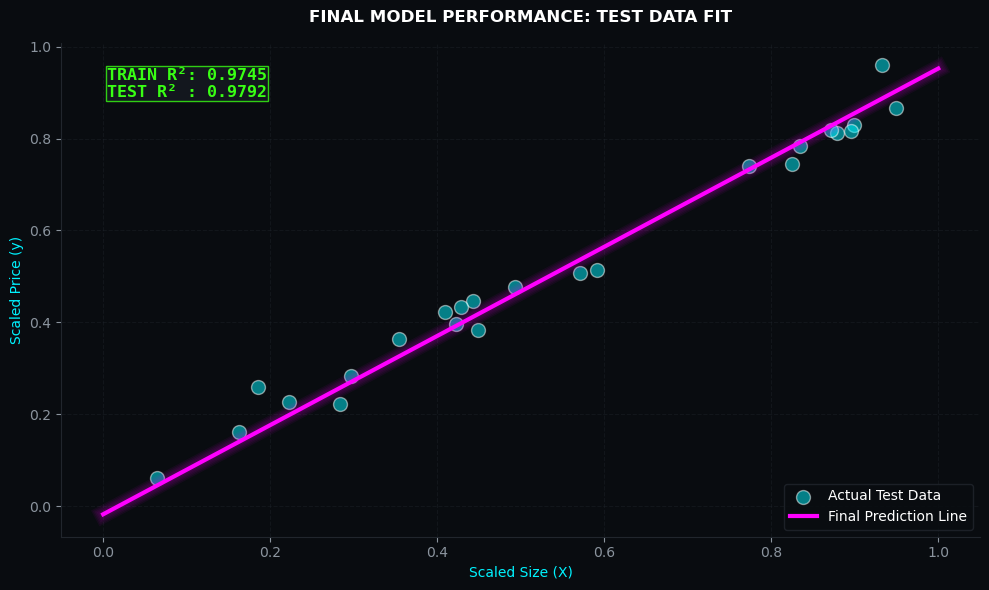

✅ Final Model Trained with α=0.7
✅ Train R²: 0.9745 | Test R²: 0.9792



In [18]:
# 7.1 TRAIN BEST MODEL

BEST_LR   = 0.7
BEST_ITER = 1500

best_model = LinearRegressionGD(learning_rate=BEST_LR, n_iterations=BEST_ITER)
best_model.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#090c10')
ax.set_facecolor('#090c10')
ax.grid(color='#21262d', linestyle='--', alpha=0.4)

ax.scatter(X_test, y_test, color='#00f3ff', s=100, alpha=0.5, edgecolors='white', label='Actual Test Data', zorder=2)

x_range = np.linspace(0, 1, 100).reshape(-1, 1)
y_range = best_model.predict(x_range)
ax.plot(x_range, y_range, color='#ff00ff', linewidth=3, label='Final Prediction Line', zorder=3)
for i in range(1, 6): # Glow loop
    ax.plot(x_range, y_range, color='#ff00ff', linewidth=3+(i*2), alpha=0.05, zorder=2)

train_r2 = best_model.score(X_train, y_train)
test_r2 = best_model.score(X_test, y_test)
info_box = f"TRAIN R²: {train_r2:.4f}\nTEST R² : {test_r2:.4f}"
ax.text(0.05, 0.95, info_box, transform=ax.transAxes, color='#39ff14',
        fontsize=12, fontweight='bold', fontfamily='monospace', verticalalignment='top',
        bbox=dict(facecolor='#161b22', edgecolor='#39ff14', alpha=0.8, pad=0.8))

apply_dark_theme(ax, 'FINAL MODEL PERFORMANCE: TEST DATA FIT', 'Scaled Size (X)', 'Scaled Price (y)')
ax.legend(facecolor='#090c10', edgecolor='#21262d', labelcolor='white')

plt.tight_layout()
plt.show()

print(f"✅ Final Model Trained with α={BEST_LR}")
print(f"✅ Train R²: {train_r2:.4f} | Test R²: {test_r2:.4f}\n")

In [19]:
# 7.2 SAVE & RELOAD MODEL (The missing step!)

best_model.save_pickle("final_model.pkl")
loaded = LinearRegressionGD.load_pickle("final_model.pkl")
print("✅ Model successfully saved to and loaded from 'final_model.pkl'\n")

✅ Model successfully saved to and loaded from 'final_model.pkl'



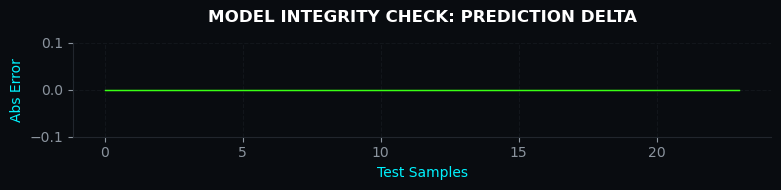

✅ Integrity Check Passed: Predictions match perfectly.


In [20]:
# 7.3 INTEGRITY CHECK

y_orig = best_model.predict(X_test).flatten()
y_load = loaded.predict(X_test).flatten()

fig, ax = plt.subplots(figsize=(8, 2))
fig.patch.set_facecolor('#090c10')
ax.set_facecolor('#090c10')
ax.grid(color='#21262d', linestyle='--', alpha=0.4)

diff = np.abs(y_orig - y_load)
ax.plot(diff, color='#39ff14', linewidth=1)
ax.fill_between(range(len(diff)), diff, color='#39ff14', alpha=0.2)

apply_dark_theme(ax, 'MODEL INTEGRITY CHECK: PREDICTION DELTA', 'Test Samples', 'Abs Error')
ax.set_ylim(-0.1, 0.1)

plt.tight_layout()
plt.show()

print("✅ Integrity Check Passed: Predictions match perfectly.")

---
## Step 8 — Evaluate on Original Scale

In [21]:
# 8.1 INVERSE SCALING (BACK TO USD)

y_pred_scaled = best_model.predict(X_test)
y_pred_usd = y_pred_scaled.flatten() * (price_max - price_min) + price_min
y_test_usd = y_test.flatten() * (price_max - price_min) + price_min

In [22]:
# 8.2 CALCULATE FINAL METRICS

mae = np.mean(np.abs(y_pred_usd - y_test_usd))
rmse = np.sqrt(np.mean((y_pred_usd - y_test_usd)**2))
r2_final = best_model.score(X_test, y_test)

print(f"\n{' STATUS: EVALUATION COMPLETE ':=^40}")
print(f"{'Metric':<10} | {'Value (USD)':<15}")
print("-" * 40)
print(f"{'MAE':<10} | ${mae:,.2f}")
print(f"{'RMSE':<10} | ${rmse:,.2f}")
print(f"{'R²':<10} | {r2_final:.4f}")
print("=" * 40 + "\n")


===== STATUS: EVALUATION COMPLETE ======
Metric     | Value (USD)    
----------------------------------------
MAE        | $16,030.11
RMSE       | $19,167.31
R²         | 0.9792



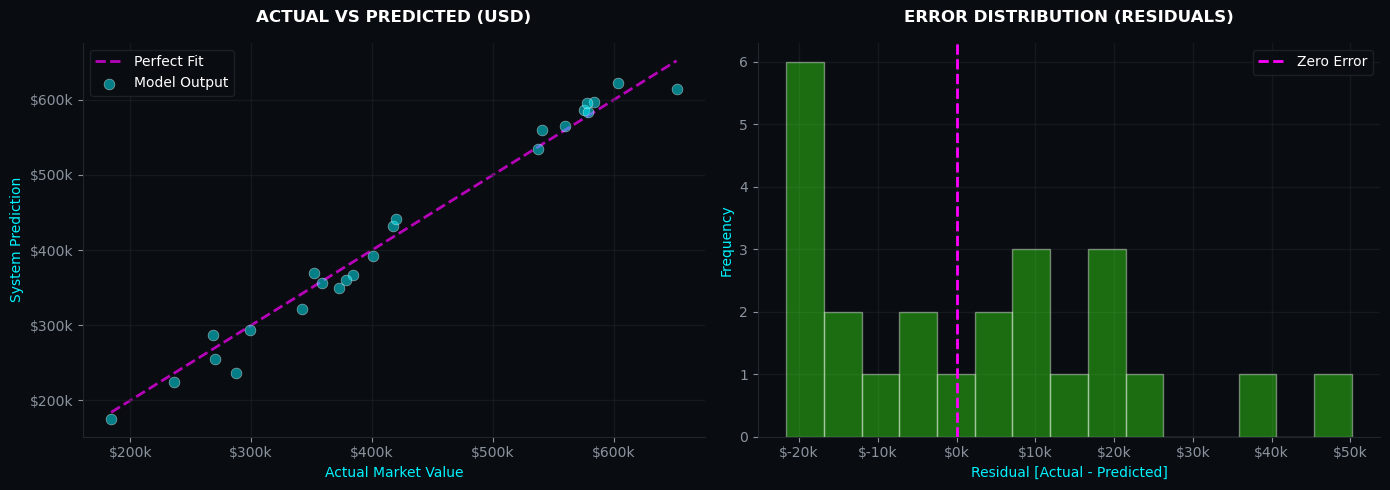

In [23]:
# 8.3 VISUAL EVALUATION (ACTUAL VS PREDICTED & RESIDUALS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#090c10')

for ax in axes:
    ax.set_facecolor('#090c10')
    ax.grid(color='#21262d', linestyle='-', linewidth=1, zorder=0)

# Plot 1: Actual vs Predicted Fit
min_val, max_val = y_test_usd.min(), y_test_usd.max()
axes[0].plot([min_val, max_val], [min_val, max_val], color='#ff00ff', linestyle='--', linewidth=2, alpha=0.7, label='Perfect Fit', zorder=1)
axes[0].scatter(y_test_usd, y_pred_usd, color='#00f3ff', s=60, alpha=0.5, edgecolors='white', linewidth=0.5, label='Model Output', zorder=2)

apply_dark_theme(axes[0], 'ACTUAL VS PREDICTED (USD)', 'Actual Market Value', 'System Prediction', 
                 y_formatter=lambda val, pos: f'${val/1000:.0f}k', x_formatter=lambda val, pos: f'${val/1000:.0f}k')
axes[0].legend(facecolor='#090c10', edgecolor='#21262d', labelcolor='white')

# Plot 2: Error Distribution (Residuals)
residuals = y_test_usd - y_pred_usd
axes[1].hist(residuals, bins=15, color='#39ff14', alpha=0.4, edgecolor='white', linewidth=1, zorder=2)
axes[1].axvline(0, color='#ff00ff', linestyle='--', linewidth=2, label='Zero Error', zorder=3)

apply_dark_theme(axes[1], 'ERROR DISTRIBUTION (RESIDUALS)', 'Residual [Actual - Predicted]', 'Frequency',
                 x_formatter=lambda val, pos: f'${val/1000:.0f}k')
axes[1].legend(facecolor='#090c10', edgecolor='#21262d', labelcolor='white')

plt.tight_layout()
plt.show()

---
## Step 9 — Compare with `sklearn`

sklearn solves θ = (XᵀX)⁻¹Xᵀy in **one step** (Normal Equation — no iterations, no α).


In [24]:
# 9.1 SKLEARN BENCHMARK

sk = LinearRegression()
sk.fit(X_train, y_train.flatten())

sk_pred_scaled = sk.predict(X_test)
sk_pred_usd = sk_pred_scaled.flatten() * (price_max - price_min) + price_min

sk_rmse = np.sqrt(mean_squared_error(y_test_usd, sk_pred_usd))
sk_r2   = r2_score(y_test_usd, sk_pred_usd)
sk_mae  = np.mean(np.abs(sk_pred_usd - y_test_usd))

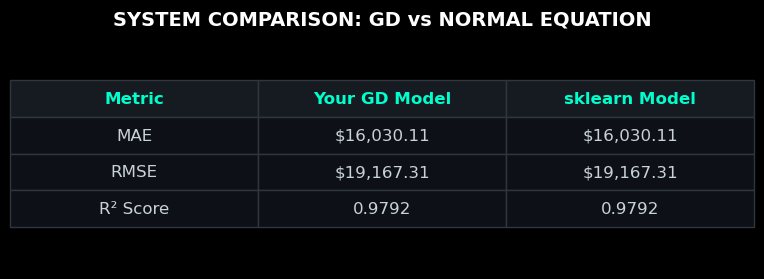

In [27]:
# 9.2 VISUAL COMPARISON TABLE

comp_data = [
    ["MAE", f"${mae:,.2f}", f"${sk_mae:,.2f}"],
    ["RMSE", f"${rmse:,.2f}", f"${sk_rmse:,.2f}"],
    ["R² Score", f"{r2_final:.4f}", f"{sk_r2:.4f}"]
]

fig_table, ax_table = plt.subplots(figsize=(8, 3))
ax_table.axis('off')
table = ax_table.table(cellText=comp_data, colLabels=["Metric", "Your GD Model", "sklearn Model"], loc='center', cellLoc='center')

style_neon_table(table) 
plt.title("SYSTEM COMPARISON: GD vs NORMAL EQUATION", color='white', fontsize=14, fontweight='bold', pad=10)
plt.show()

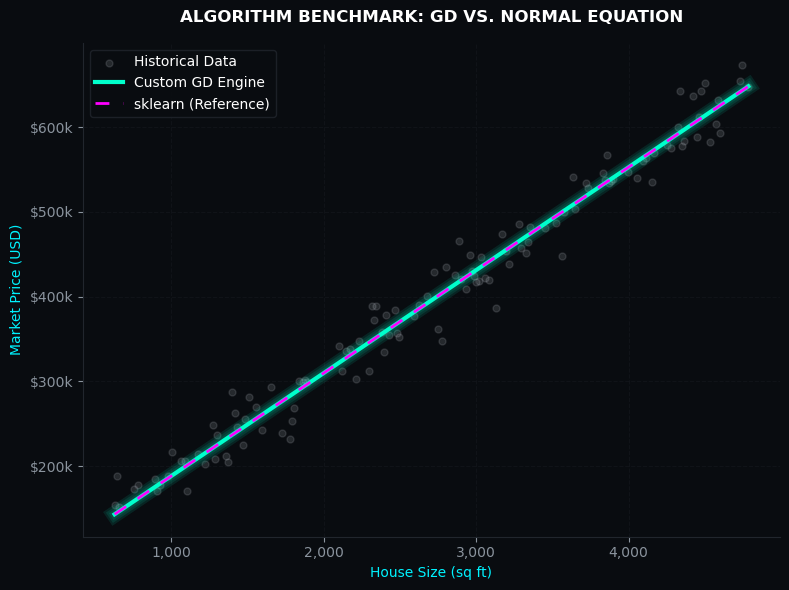

In [32]:
# --- 9.3 COMPARISON PLOT ---

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#090c10')
ax.set_facecolor('#090c10')

ax.grid(color='#21262d', linestyle='--', alpha=0.3, zorder=0)

ax.scatter(size_sqft, price_usd, color='#c9d1d9', s=25, alpha=0.15, label='Historical Data', zorder=1)

ax.plot(line_x, gd_y_usd, color=NEON_CYAN, linewidth=3, label='Custom GD Engine', zorder=4)
for i in range(1, 4):
    ax.plot(line_x, gd_y_usd, color=NEON_CYAN, linewidth=3+(i*3), alpha=0.1, zorder=3)

ax.plot(line_x, sk_y_usd, color='#ff00ff', linestyle=(0, (5, 5)), linewidth=2, label='sklearn (Reference)', zorder=5)

apply_dark_theme(ax, 'ALGORITHM BENCHMARK: GD VS. NORMAL EQUATION', 'House Size (sq ft)', 'Market Price (USD)',
                 y_formatter=lambda val, pos: f'${val/1000:.0f}k', x_formatter=lambda val, pos: f'{val:,.0f}')

ax.legend(facecolor='#090c10', edgecolor='#21262d', labelcolor='white', loc='upper left', framealpha=0.8)

plt.tight_layout()
plt.show()

In [29]:
# --- 9.4 FINAL INFERENCE ---

TARGET_SQFT = 2200
target_scaled = (TARGET_SQFT - size_min) / (size_max - size_min)

pred_usd_gd = (loaded.predict(np.array([target_scaled]))[0] * (price_max - price_min)) + price_min
pred_usd_sk = (sk.predict(np.array([[target_scaled]]))[0] * (price_max - price_min)) + price_min
variance = abs(pred_usd_gd - pred_usd_sk)

print(f"\n{' FINAL INFERENCE: REAL ESTATE ESTIMATION ':=^50}")
print(f"{'Target Parameter':<20} | {TARGET_SQFT} sq ft")
print("-" * 50)
print(f"{'Custom GD Estimate':<20} | ${pred_usd_gd:,.2f}")
print(f"{'Sklearn Estimate':<20} | ${pred_usd_sk:,.2f}")
print(f"{'Model Variance (Δ)':<20} | ${variance:,.2f}")
print("=" * 50)

status = "🎯 HIGH INTEGRITY" if variance < 500 else "⚠️ MARGINAL VARIANCE"
print(f"STATUS: {status}")


==== FINAL INFERENCE: REAL ESTATE ESTIMATION =====
Target Parameter     | 2200 sq ft
--------------------------------------------------
Custom GD Estimate   | $334,086.06
Sklearn Estimate     | $334,086.06
Model Variance (Δ)   | $0.00
STATUS: 🎯 HIGH INTEGRITY


---
## Step 10 — Final Questions *(write answers below each)*

**Q4.** Your GD model and sklearn produced almost the same regression line. Why do two totally different algorithms reach the same answer?

> *Answer:* Both algorithms aim to minimize the same Mean Squared Error (MSE) cost function. Since this function for Linear Regression is convex (bowl-shaped), it has only one unique global minimum. Whether we use an iterative approach like Gradient Descent or a closed-form mathematical solution like the Normal Equation, both paths lead to the same optimal parameters ($\theta_0$ and $\theta_1$).

**Q5.** You saved the model as a `.pkl` file. Why is saving important in real ML projects?

> *Answer:* Model Persistence (saving) is crucial because training complex models can take significant time and computational resources. By saving the trained "weights" as a .pkl file, we can "train once and deploy anywhere." This allows the model to be integrated into production environments, such as web servers or mobile apps, to provide instant predictions without needing the original training data or re-training.

**Q6.** If someone copied your notebook and ran it, would they get the same θ₀, θ₁, and predicted price as you? Why or why not?

> *Answer:* Yes, they would, because we used a fixed random_state=4420 during the data split. In computing, randomness is actually pseudo-random; providing a specific "seed" ensures that the shuffling and splitting of the dataset are deterministic. This reproducibility is vital in scientific research and collaborative development to ensure consistent results across different environments.

---
## ✅ Checklist Before Submitting

- [ ✅ ] Step 2 — EDA: two plots + manual correlation
- [ ✅ ] Step 3 — Scaling asserts pass, 80/20 split
- [ ✅ ] Step 4 — All 8 methods implemented
- [ ✅ ] Step 5 — All 5 unit tests pass
- [ ✅ ] Step 6 — Table + 1×5 grid + overlay + 3 written answers
- [ ✅ ] Step 7 — Best model saved and reloaded
- [ ✅ ] Step 8 — MAE, RMSE, R² (manual) + two plots
- [ ✅ ] Step 9 — sklearn table + overlay + prediction for **2200 sq ft**
- [ ✅ ] Step 10 — Q4, Q5, Q6 answered

*`LR-CS-04-4420`*